In [31]:
from interface import *
from visualize import *

import random
import stim
import numpy as np

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf) # type: ignore

%load_ext autoreload
%aimport interface.chip
%aimport interface.models
%aimport visualize.visualize
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Basic Chip Demo

Creating a basic l=5 x h=5 chip results in an underlying grid structure ranging from (0,0) to (2l, 2h). The chip is in a checkerboard style, where valid (x, y) coords have the property of x%2 == y%2. The chip can be visualized by using `chip.show()`

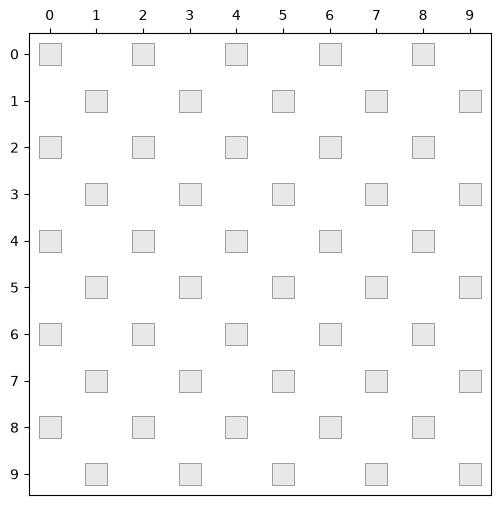

<Axes: >

In [32]:
chip = Chip(5,5)
chip.show()

In [33]:
chip.loc((0,0)).status = Status.LOGICAL
chip.loc((5,5)).status = Status.ANCILLA
print(chip.loc((0,0)))
print(chip.loc((5,5)))

Qubit(loc=(0, 0), status=Status.LOGICAL, noise=NoiseProfile(p=0.0))
Qubit(loc=(5, 5), status=Status.ANCILLA, noise=NoiseProfile(p=0.0))


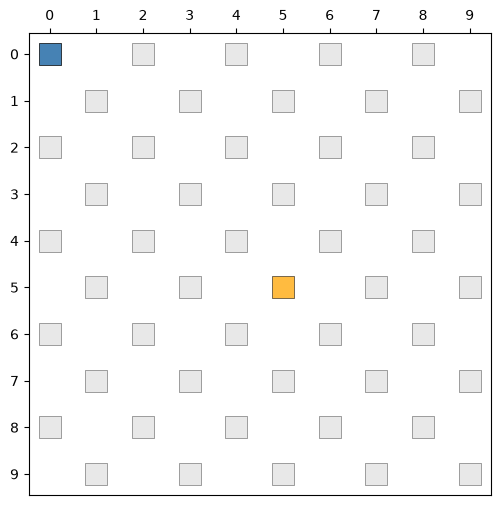

<Axes: >

In [34]:
chip.show(style=default_style)

In [35]:
chip.generate_random_noise()
chip.loc((2, 2)).noise.p = .06
print(chip.loc((2, 2)))
print(chip.noise_map)

Qubit(loc=(2, 2), status=Status.INACTIVE, noise=NoiseProfile(p=0.06))
{(0, 0): NoiseProfile(p=0.0478), (0, 2): NoiseProfile(p=0.0269), (0, 4): NoiseProfile(p=0.03954), (0, 6): NoiseProfile(p=0.02043), (0, 8): NoiseProfile(p=0.03185), (1, 1): NoiseProfile(p=0.01055), (1, 3): NoiseProfile(p=0.03957), (1, 5): NoiseProfile(p=0.0233), (1, 7): NoiseProfile(p=0.02233), (1, 9): NoiseProfile(p=0.04857), (2, 0): NoiseProfile(p=0.03289), (2, 2): NoiseProfile(p=0.06), (2, 4): NoiseProfile(p=0.0424), (2, 6): NoiseProfile(p=0.01071), (2, 8): NoiseProfile(p=0.01203), (3, 1): NoiseProfile(p=0.03982), (3, 3): NoiseProfile(p=0.04108), (3, 5): NoiseProfile(p=0.03476), (3, 7): NoiseProfile(p=0.02577), (3, 9): NoiseProfile(p=0.04608), (4, 0): NoiseProfile(p=0.0338), (4, 2): NoiseProfile(p=0.01085), (4, 4): NoiseProfile(p=0.0225), (4, 6): NoiseProfile(p=0.04395), (4, 8): NoiseProfile(p=0.02372), (5, 1): NoiseProfile(p=0.03164), (5, 3): NoiseProfile(p=0.01641), (5, 5): NoiseProfile(p=0.02374), (5, 7): NoiseP

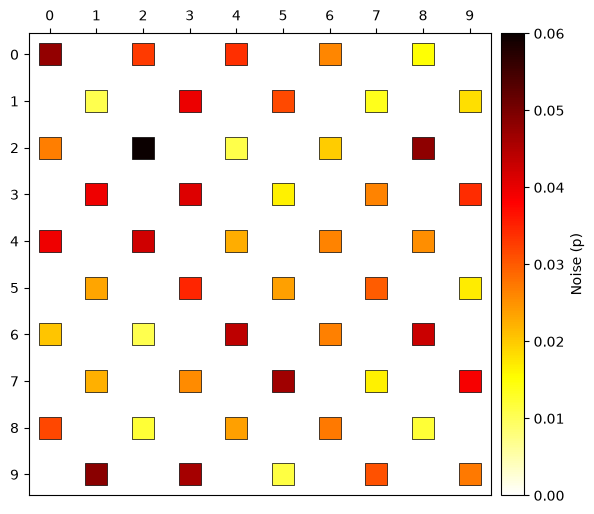

<Axes: >

In [36]:
chip.show(style=noise_heatmap_style(chip, limits =(0.0, 0.06)))

## Logical Tile Placement and Shifts

Chips are a workspace for tiles, that represent logical qubits created from STIM circuits. To create a tile, provide a STIM circuit. The size and qubit coordinates are automatically pulled from the file. Once a chip has been instantiated, you can add tiles for a given coordinate, which represents the upper leftmost qubit of the tile.

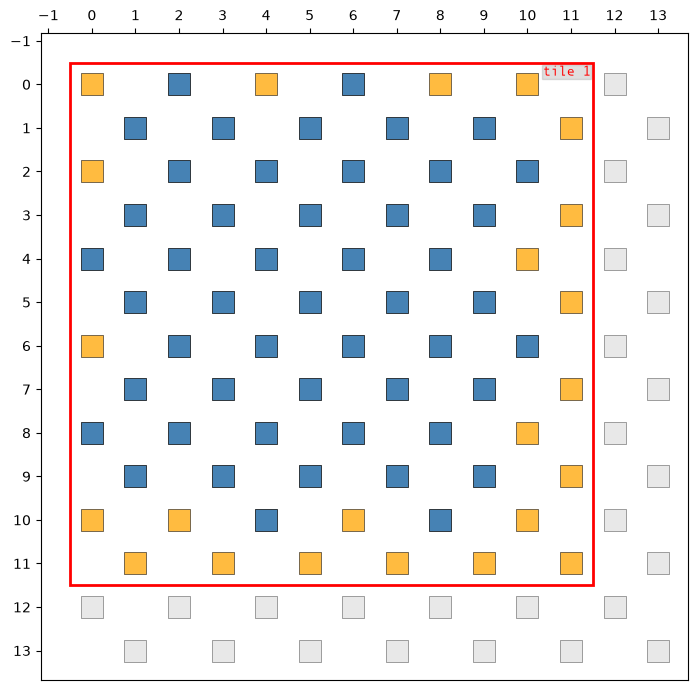

<Axes: >

In [37]:
chip = Chip(7,7)
tile = LogicalTile(circuit=stim.Circuit.generated(code_task='surface_code:rotated_memory_z', distance=5, rounds=3), tag=TileTag(distance=5))
chip.add_tile(tile, loc=(0,0))
chip.generate_random_noise()
chip.show()

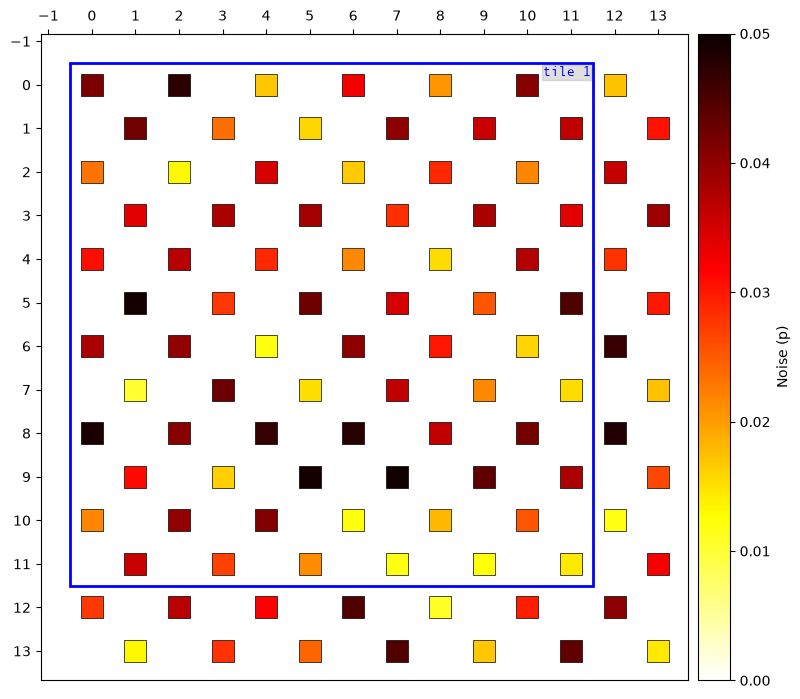

<Axes: >

In [38]:
chip.show(style=noise_heatmap_style(chip, limits=(0.0,0.05)))

In [39]:
chip.tiles[0].qubits

[Qubit(loc=(2, 0), status=Status.LOGICAL, noise=NoiseProfile(p=0.04744)),
 Qubit(loc=(0, 0), status=Status.ANCILLA, noise=NoiseProfile(p=0.04153)),
 Qubit(loc=(3, 1), status=Status.LOGICAL, noise=NoiseProfile(p=0.0236)),
 Qubit(loc=(1, 1), status=Status.LOGICAL, noise=NoiseProfile(p=0.04234)),
 Qubit(loc=(0, 2), status=Status.ANCILLA, noise=NoiseProfile(p=0.02317)),
 Qubit(loc=(2, 2), status=Status.LOGICAL, noise=NoiseProfile(p=0.01309)),
 Qubit(loc=(3, 3), status=Status.LOGICAL, noise=NoiseProfile(p=0.0379)),
 Qubit(loc=(1, 3), status=Status.LOGICAL, noise=NoiseProfile(p=0.03383)),
 Qubit(loc=(0, 4), status=Status.LOGICAL, noise=NoiseProfile(p=0.03076)),
 Qubit(loc=(2, 4), status=Status.LOGICAL, noise=NoiseProfile(p=0.03704)),
 Qubit(loc=(4, 0), status=Status.ANCILLA, noise=NoiseProfile(p=0.01685)),
 Qubit(loc=(6, 0), status=Status.LOGICAL, noise=NoiseProfile(p=0.03249)),
 Qubit(loc=(5, 1), status=Status.LOGICAL, noise=NoiseProfile(p=0.01568)),
 Qubit(loc=(7, 1), status=Status.LOGICAL

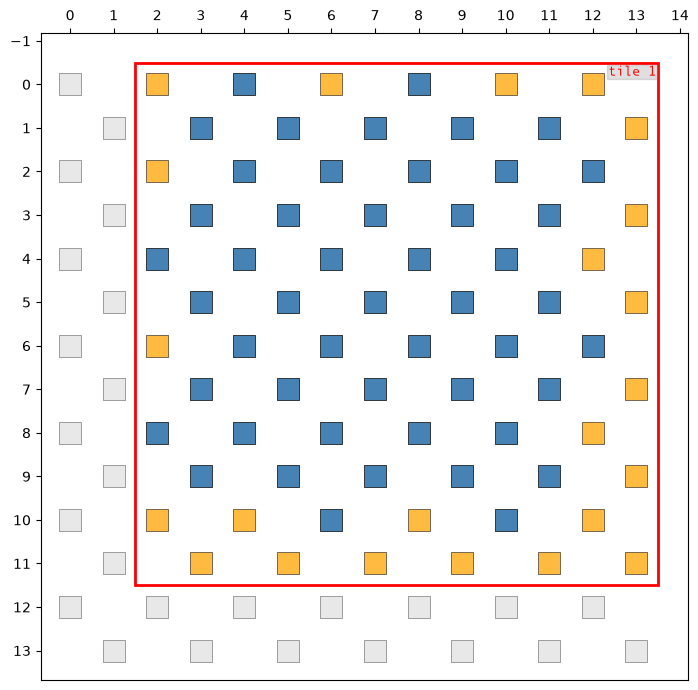

(2.0, 0.0)


In [40]:
chip.tiles[0].shift_by(2,0)
chip.show()
print(chip.tiles[0].origin)

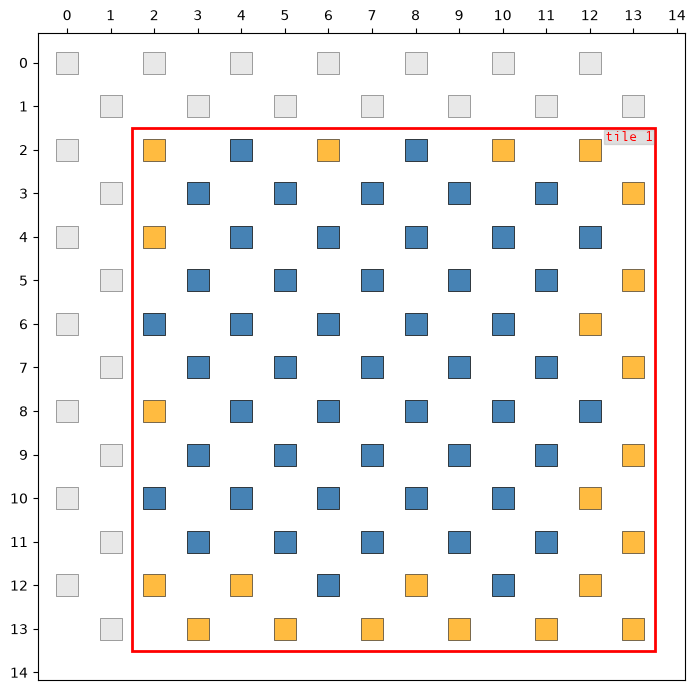

(2.0, 2.0)


In [41]:
chip.tiles[0].shift_by(0, 2)
chip.show()
print(chip.tiles[0].origin)

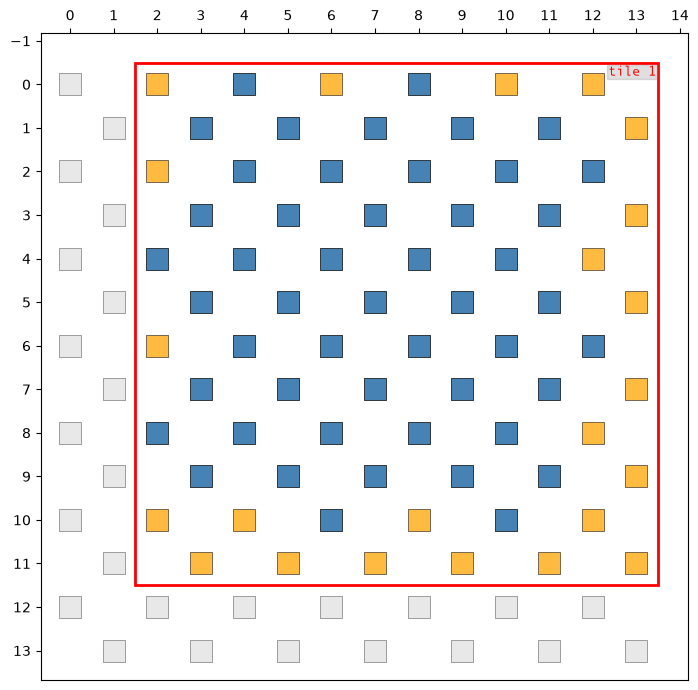

(2.0, 0.0)


In [42]:
chip.tiles[0].shift_by(0, -2)
chip.show()
print(chip.tiles[0].origin)

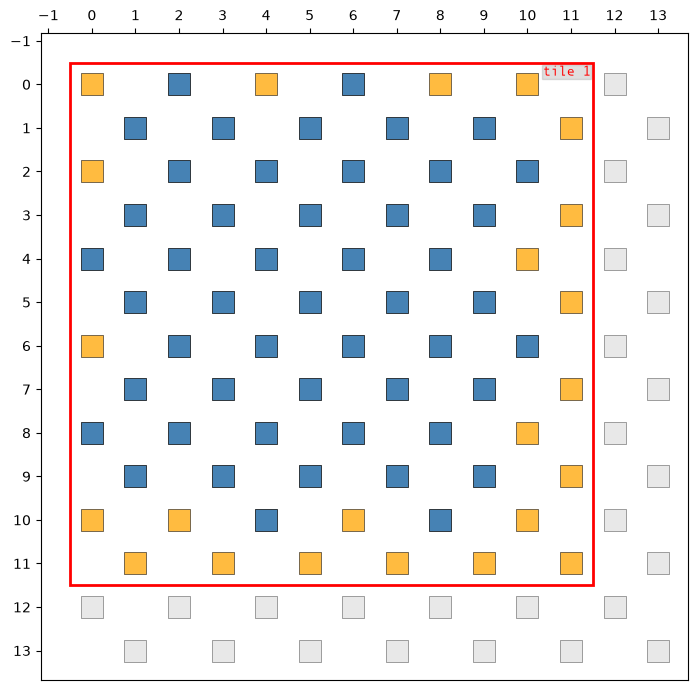

(0.0, 0.0)


In [43]:
chip.tiles[0].shift_by(-2, 0)
chip.show()
print(chip.tiles[0].origin)

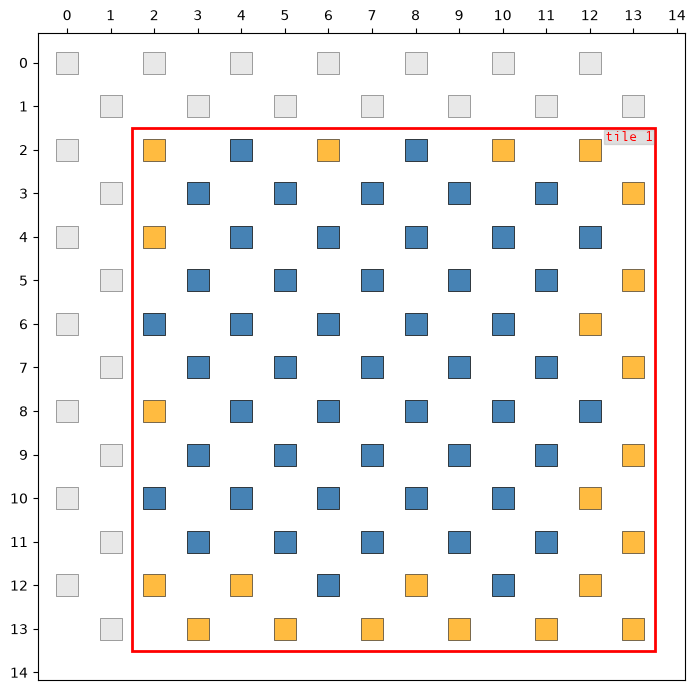

<Axes: >

In [44]:
chip.tiles[0].shift_to((2,2))
chip.show()

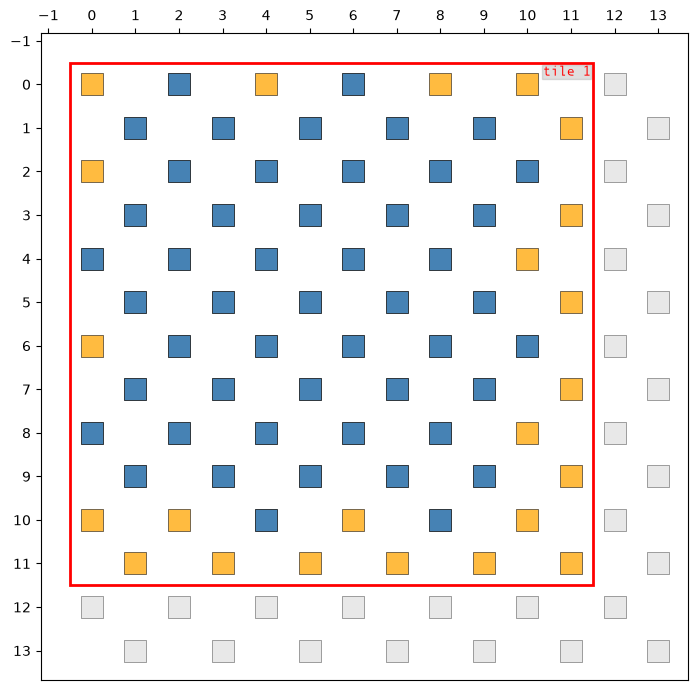

<Axes: >

In [45]:
chip.tiles[0].shift_to((0,0))
chip.show()

## Multi-Tile Demo

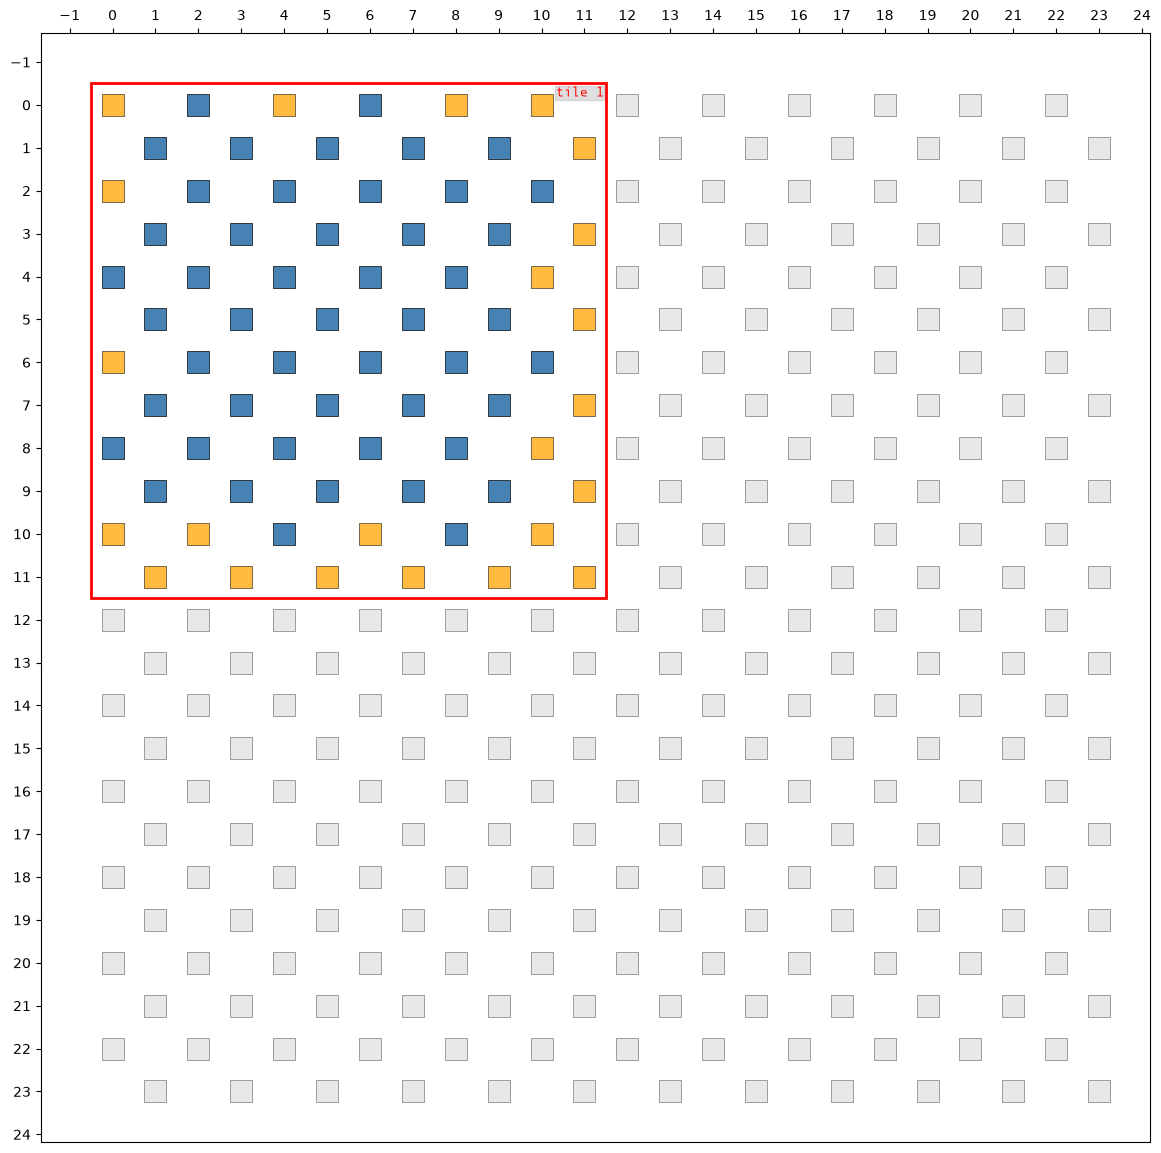

<Axes: >

In [46]:
tile3 = LogicalTile(circuit=stim.Circuit.generated(code_task='surface_code:rotated_memory_z', distance=5, rounds=3), tag=TileTag(distance=5))
chip3 = Chip(12, 12)
chip3.generate_random_noise((0.0,0.05))
chip3.add_tile(tile3,loc=(0,0))
chip3.show()

In [47]:
chip3.add_tile(tile3.copy(),loc=(12,0))
chip3.add_tile(tile3.copy(),loc=(0,12))
chip3.add_tile(tile3.copy(),loc=(12,12))

True

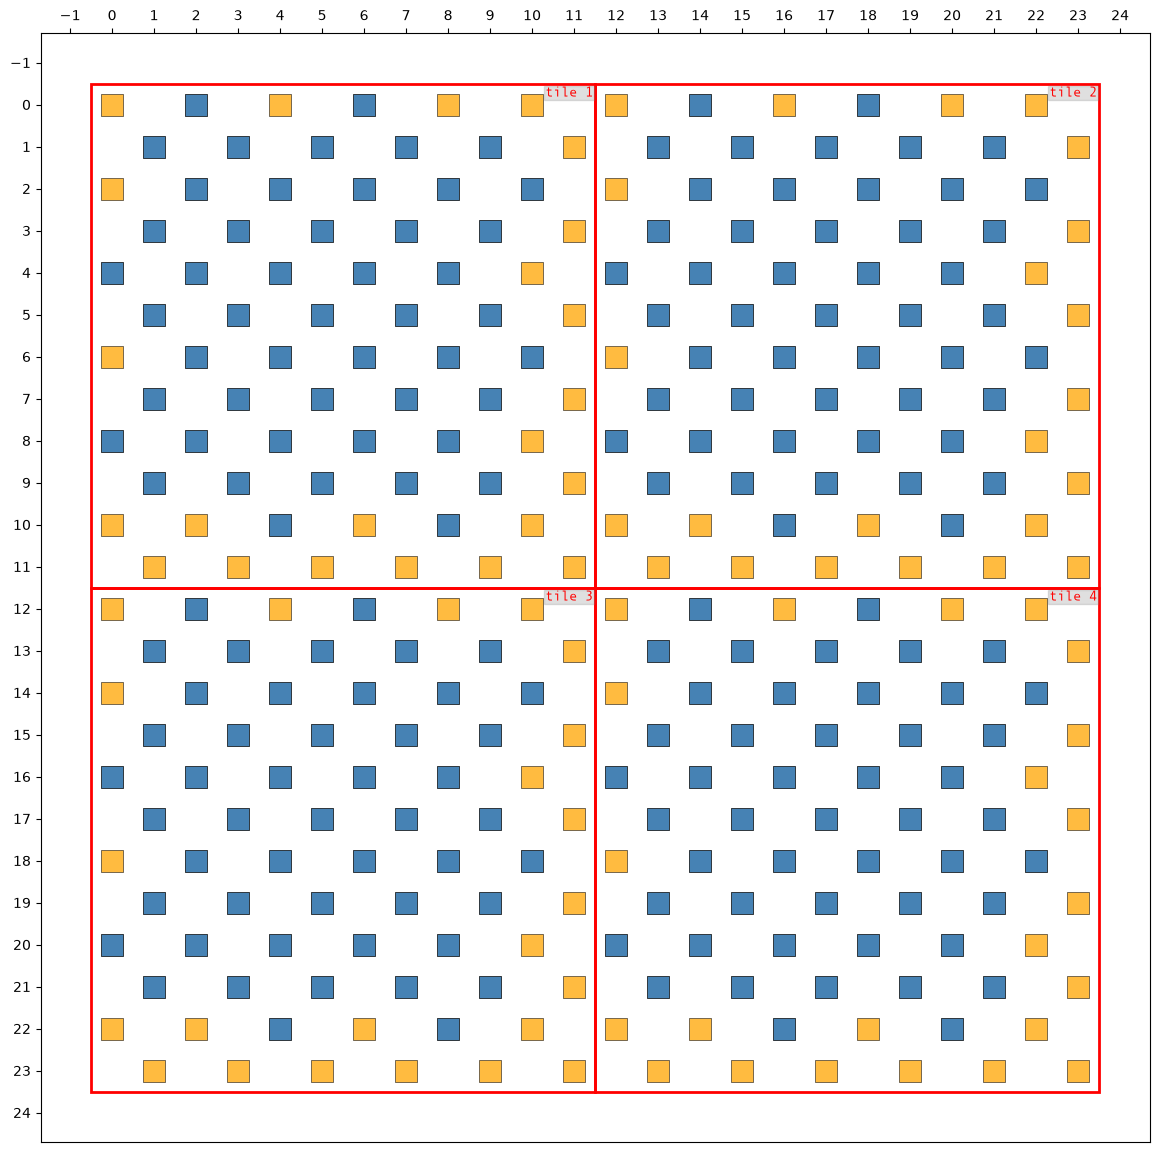

<Axes: >

In [48]:
chip3.show()

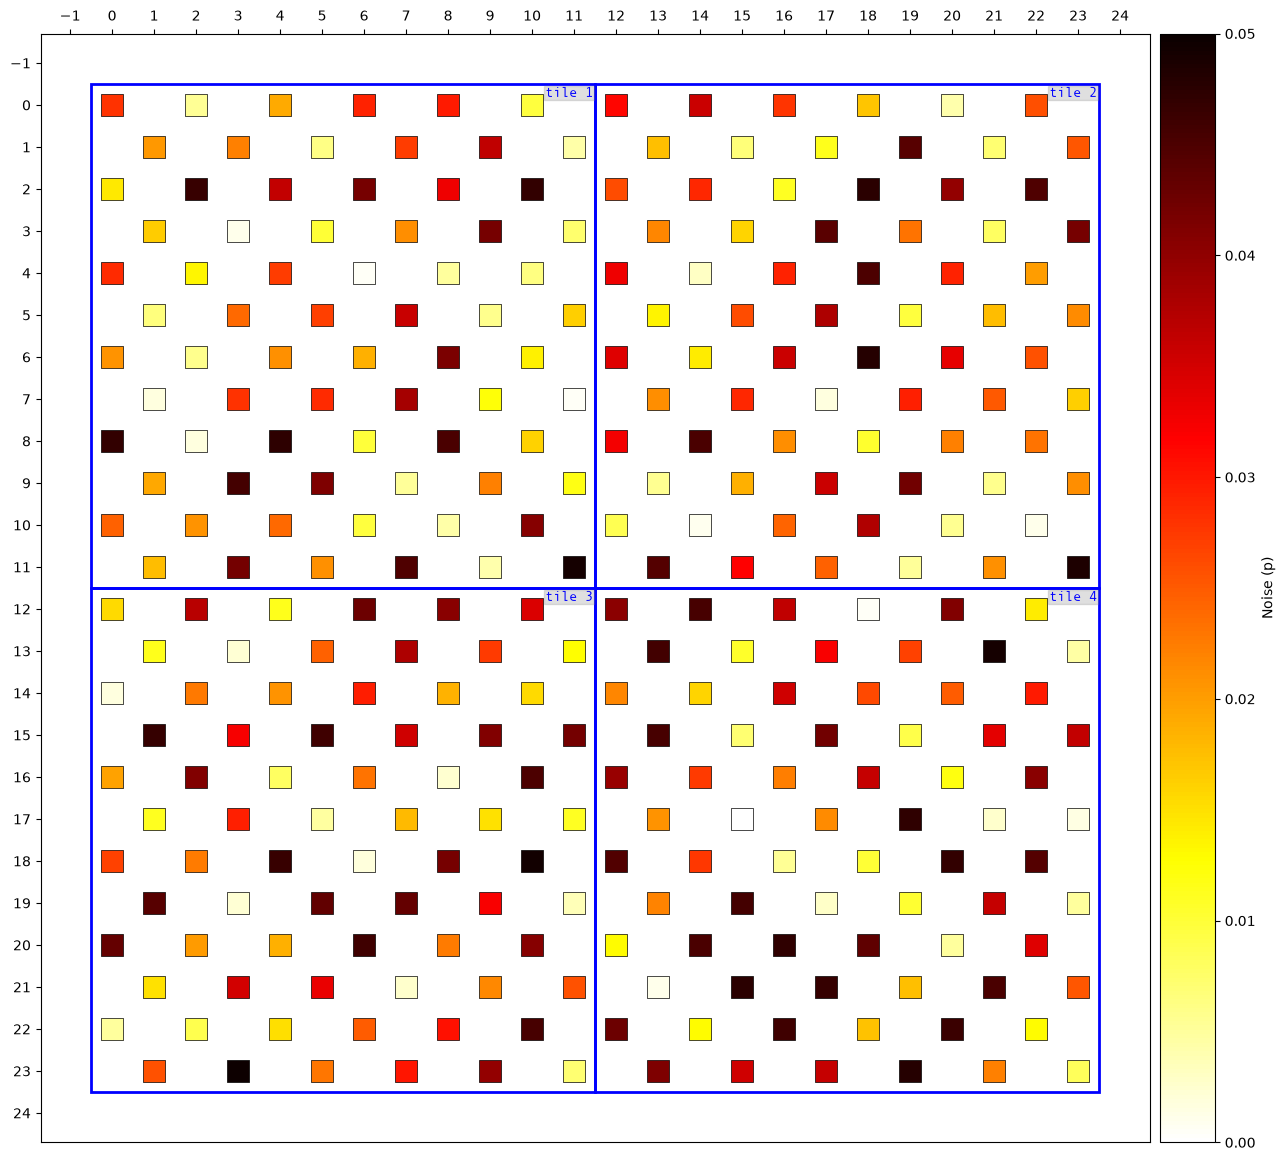

<Axes: >

In [49]:
chip3.show(style=noise_heatmap_style(chip3, limits=(0.0, 0.05)))

## Multi Tile With Various Distances

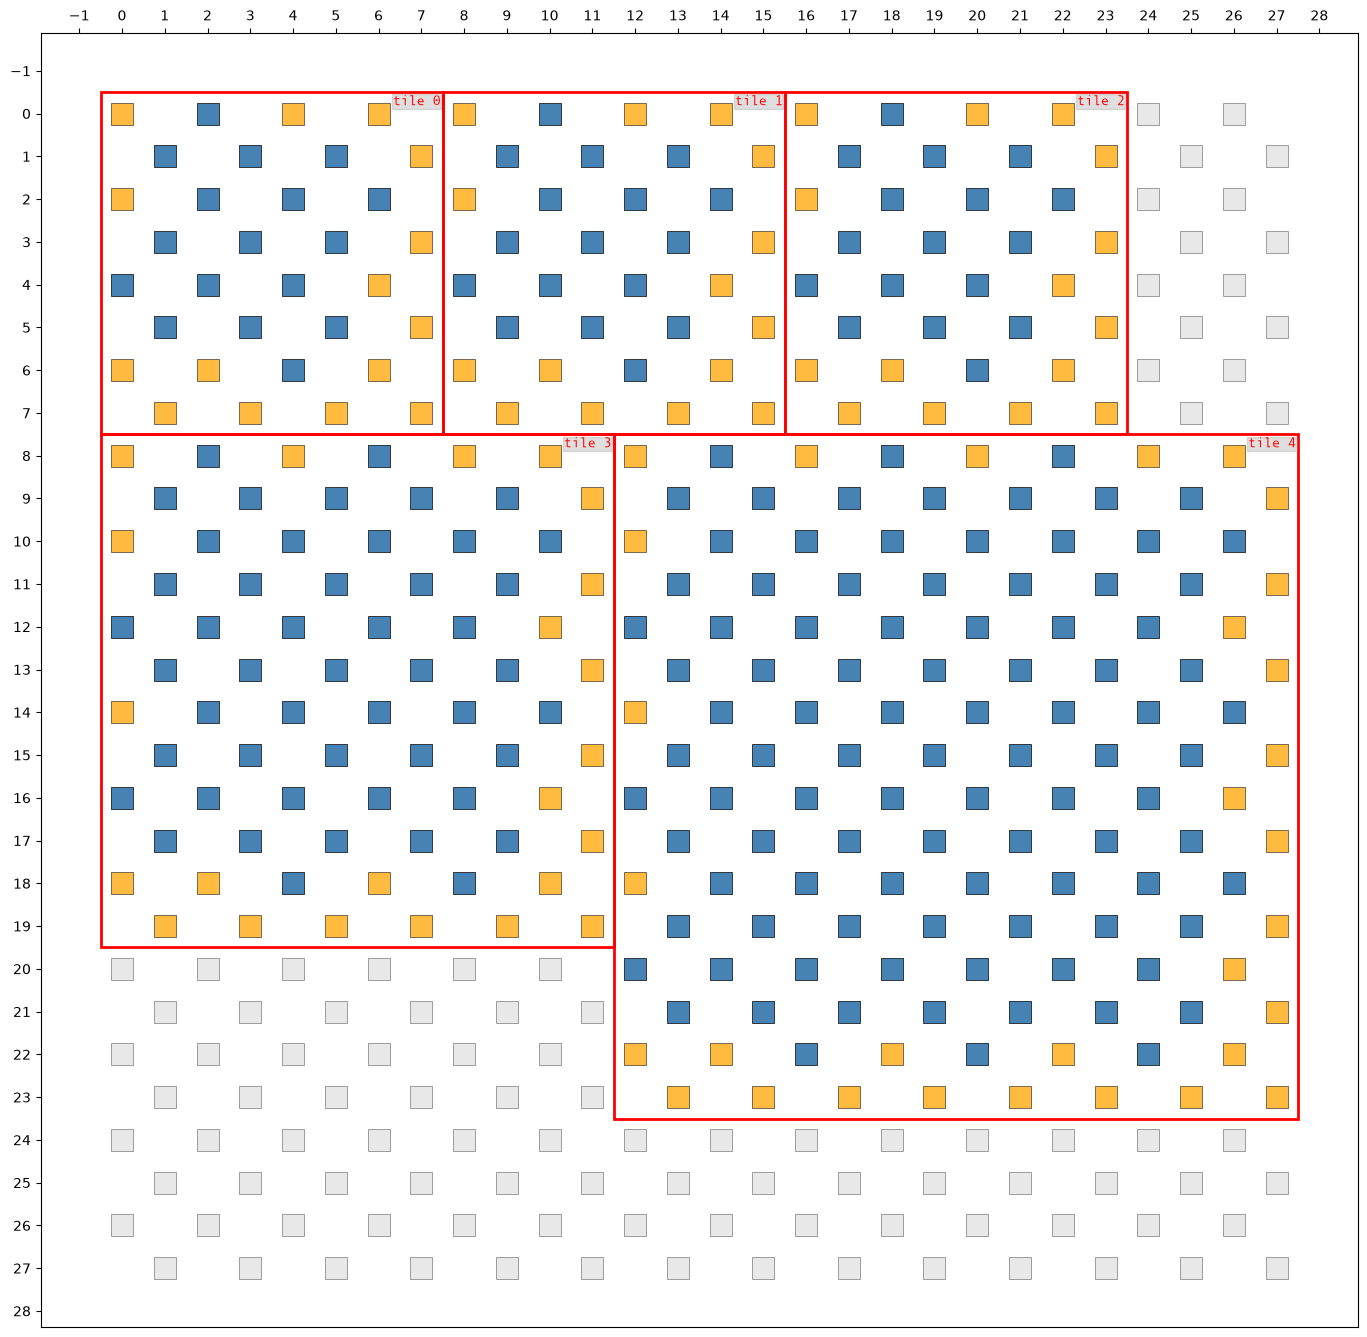

<Axes: >

In [94]:
d3Tile = LogicalTile(circuit=stim.Circuit.generated(code_task='surface_code:rotated_memory_z', distance=3, rounds=3), tag=TileTag(distance=3))
d5Tile = LogicalTile(circuit=stim.Circuit.generated(code_task='surface_code:rotated_memory_z', distance=5, rounds=3), tag=TileTag(distance=5))
d7Tile = LogicalTile(circuit=stim.Circuit.generated(code_task='surface_code:rotated_memory_z', distance=7, rounds=3), tag=TileTag(distance=7))

chip4 = Chip(14, 14)
chip4.generate_random_noise((0.0,0.05))
chip4.add_tile(d3Tile.copy(),loc=(0,0))
chip4.add_tile(d3Tile.copy(),loc=(8,0))
chip4.add_tile(d3Tile.copy(),loc=(16,0))

chip4.add_tile(d5Tile.copy(),loc=(0,8))

chip4.add_tile(d7Tile.copy(),loc=(12,8))

# chip4.add_tile(d7Tile.copy(),loc=(12,8))
chip4.show()

In [92]:
chip4.tiles[0].circuit

stim.Circuit('''
    QUBIT_COORDS(1, 9) 1
    QUBIT_COORDS(2, 8) 2
    QUBIT_COORDS(3, 9) 3
    QUBIT_COORDS(5, 9) 5
    QUBIT_COORDS(6, 8) 6
    QUBIT_COORDS(7, 9) 7
    QUBIT_COORDS(9, 9) 9
    QUBIT_COORDS(1, 11) 12
    QUBIT_COORDS(2, 10) 13
    QUBIT_COORDS(3, 11) 14
    QUBIT_COORDS(4, 10) 15
    QUBIT_COORDS(5, 11) 16
    QUBIT_COORDS(6, 10) 17
    QUBIT_COORDS(7, 11) 18
    QUBIT_COORDS(8, 10) 19
    QUBIT_COORDS(9, 11) 20
    QUBIT_COORDS(10, 10) 21
    QUBIT_COORDS(0, 12) 22
    QUBIT_COORDS(1, 13) 23
    QUBIT_COORDS(2, 12) 24
    QUBIT_COORDS(3, 13) 25
    QUBIT_COORDS(4, 12) 26
    QUBIT_COORDS(5, 13) 27
    QUBIT_COORDS(6, 12) 28
    QUBIT_COORDS(7, 13) 29
    QUBIT_COORDS(8, 12) 30
    QUBIT_COORDS(9, 13) 31
    QUBIT_COORDS(1, 15) 34
    QUBIT_COORDS(2, 14) 35
    QUBIT_COORDS(3, 15) 36
    QUBIT_COORDS(4, 14) 37
    QUBIT_COORDS(5, 15) 38
    QUBIT_COORDS(6, 14) 39
    QUBIT_COORDS(7, 15) 40
    QUBIT_COORDS(8, 14) 41
    QUBIT_COORDS(9, 15) 42
    QUBIT_COORDS(10, 14)

In [84]:
stim.Circuit.generated(code_task='surface_code:rotated_memory_z', distance=5, rounds=3)

stim.Circuit('''
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(2, 0) 2
    QUBIT_COORDS(3, 1) 3
    QUBIT_COORDS(5, 1) 5
    QUBIT_COORDS(6, 0) 6
    QUBIT_COORDS(7, 1) 7
    QUBIT_COORDS(9, 1) 9
    QUBIT_COORDS(1, 3) 12
    QUBIT_COORDS(2, 2) 13
    QUBIT_COORDS(3, 3) 14
    QUBIT_COORDS(4, 2) 15
    QUBIT_COORDS(5, 3) 16
    QUBIT_COORDS(6, 2) 17
    QUBIT_COORDS(7, 3) 18
    QUBIT_COORDS(8, 2) 19
    QUBIT_COORDS(9, 3) 20
    QUBIT_COORDS(10, 2) 21
    QUBIT_COORDS(0, 4) 22
    QUBIT_COORDS(1, 5) 23
    QUBIT_COORDS(2, 4) 24
    QUBIT_COORDS(3, 5) 25
    QUBIT_COORDS(4, 4) 26
    QUBIT_COORDS(5, 5) 27
    QUBIT_COORDS(6, 4) 28
    QUBIT_COORDS(7, 5) 29
    QUBIT_COORDS(8, 4) 30
    QUBIT_COORDS(9, 5) 31
    QUBIT_COORDS(1, 7) 34
    QUBIT_COORDS(2, 6) 35
    QUBIT_COORDS(3, 7) 36
    QUBIT_COORDS(4, 6) 37
    QUBIT_COORDS(5, 7) 38
    QUBIT_COORDS(6, 6) 39
    QUBIT_COORDS(7, 7) 40
    QUBIT_COORDS(8, 6) 41
    QUBIT_COORDS(9, 7) 42
    QUBIT_COORDS(10, 6) 43
    QUBIT_COORDS(0, 8) 44


In [81]:
chip4.tiles[0].qubits

[Qubit(loc=(0, 8), status=Status.ANCILLA, noise=NoiseProfile(p=0.01789)),
 Qubit(loc=(2, 8), status=Status.ANCILLA, noise=NoiseProfile(p=0.02078)),
 Qubit(loc=(3, 9), status=Status.LOGICAL, noise=NoiseProfile(p=0.03322)),
 Qubit(loc=(1, 9), status=Status.LOGICAL, noise=NoiseProfile(p=0.04642)),
 Qubit(loc=(4, 8), status=Status.LOGICAL, noise=NoiseProfile(p=0.02031)),
 Qubit(loc=(6, 8), status=Status.ANCILLA, noise=NoiseProfile(p=0.00598)),
 Qubit(loc=(7, 9), status=Status.LOGICAL, noise=NoiseProfile(p=0.03956)),
 Qubit(loc=(5, 9), status=Status.LOGICAL, noise=NoiseProfile(p=0.04989)),
 Qubit(loc=(8, 8), status=Status.LOGICAL, noise=NoiseProfile(p=0.00177)),
 Qubit(loc=(10, 8), status=Status.ANCILLA, noise=NoiseProfile(p=0.02182)),
 Qubit(loc=(11, 9), status=Status.ANCILLA, noise=NoiseProfile(p=0.02994)),
 Qubit(loc=(9, 9), status=Status.LOGICAL, noise=NoiseProfile(p=0.00651)),
 Qubit(loc=(0, 10), status=Status.LOGICAL, noise=NoiseProfile(p=0.02425)),
 Qubit(loc=(2, 10), status=Status.L

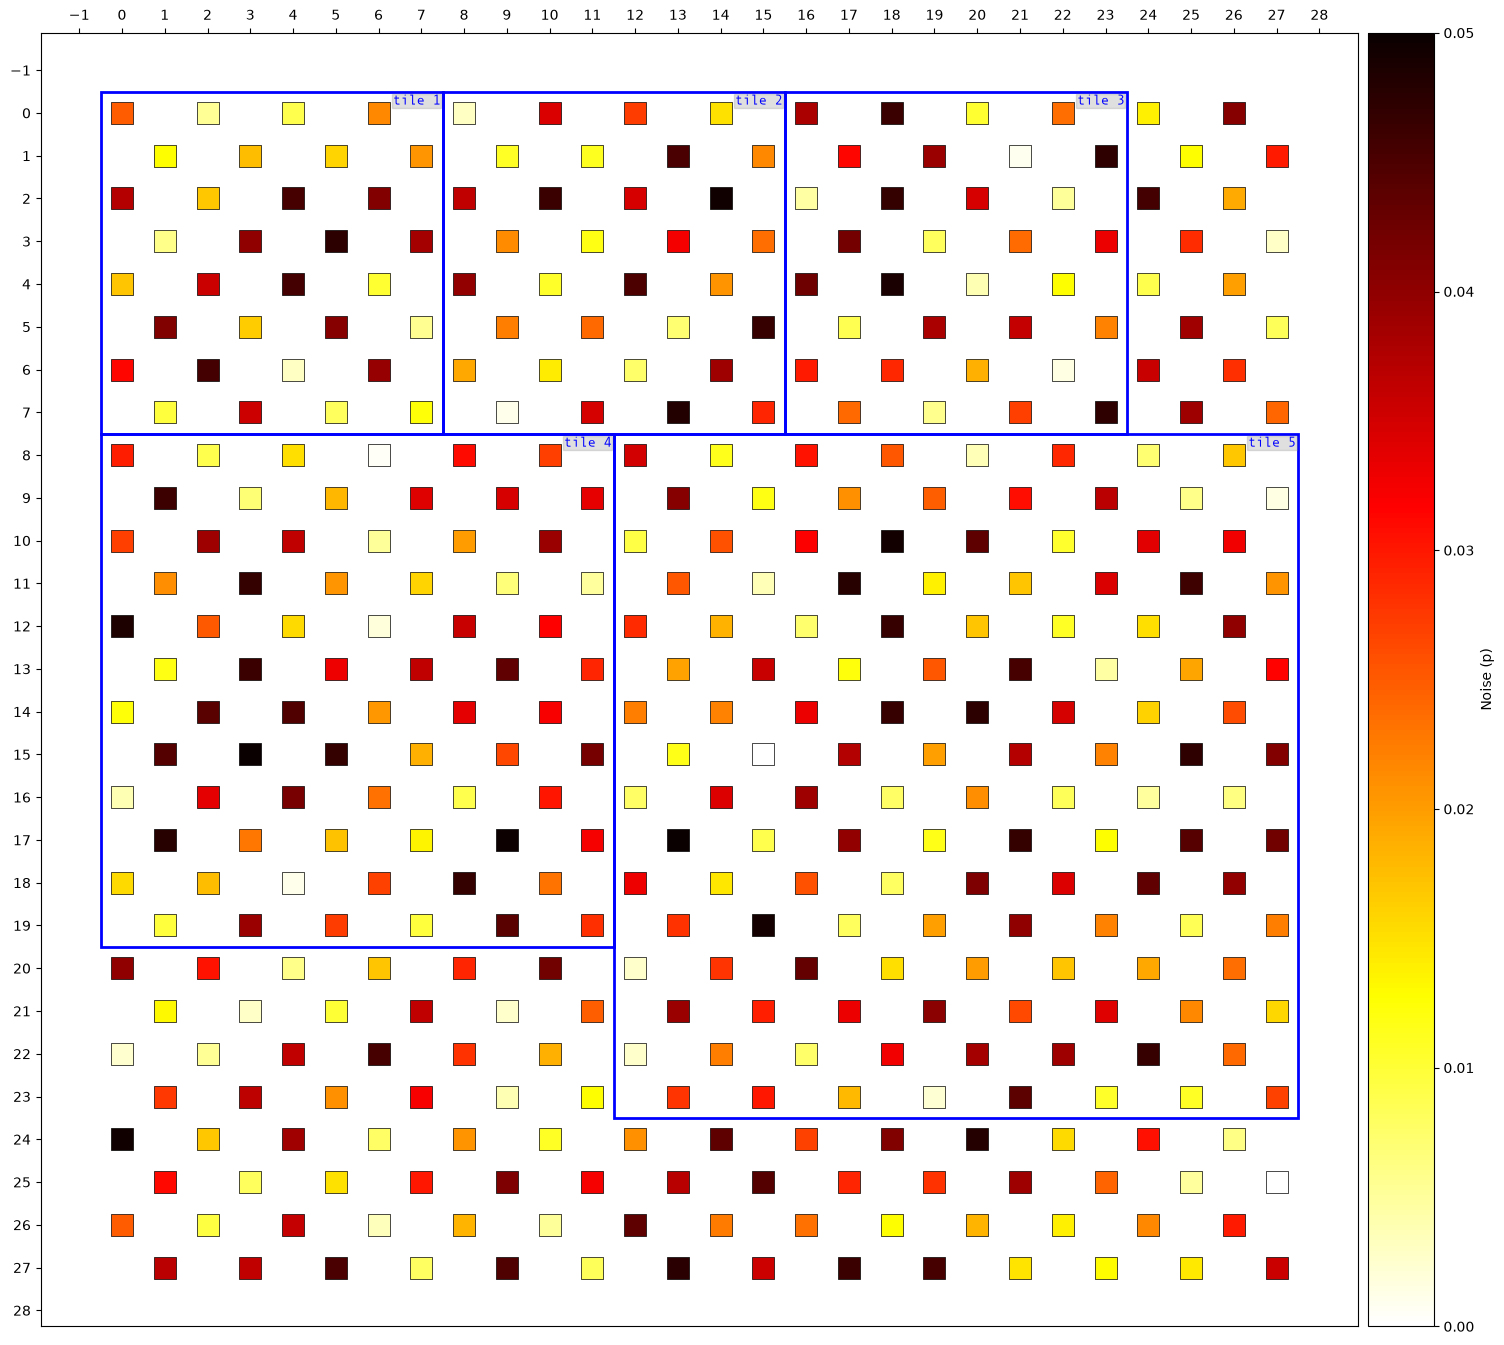

<Axes: >

In [51]:
chip4.show(noise_heatmap_style(chip4, limits=(0.0, 0.05)))